# 07 · Enhanced Bayesian Optimisation Pipeline

## 1 · Imports & Setup

In [1]:
import os
import sys
import warnings
from pathlib import Path

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

# ── path setup ────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve().parent  
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

from statarb.context  import AppContext
from statarb.pipeline import EnhancedPipelineV1_P3
from statarb.fitter   import OLSFitter, VECMFitter
from statarb.evolver  import StaticEvolver, KalmanEvolver
from statarb.backtest import make_daily_rates
from statarb.metrics  import get_backtest_metrics, save_strategy_outputs

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s  %(levelname)-8s  %(message)s',
                    datefmt='%H:%M:%S')
warnings.filterwarnings('ignore')

ctx = AppContext.instance()
cfg = ctx.cfg

OUTPUT_DIR = Path(cfg['data']['output_dir'])
TEST_DIR   = Path(cfg['data']['test_dir'])
PLOT_DIR   = Path(cfg['data']['plot_dir'])
TEST_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

STRATEGIES = [
    ('Static_OLS',  OLSFitter,  StaticEvolver),
    ('Static_VECM', VECMFitter, StaticEvolver),
    ('Kalman_OLS',  OLSFitter,  KalmanEvolver),
    ('Kalman_VECM', VECMFitter, KalmanEvolver),
]
METHODS = ['corr', 'dist', 'coint', 'combined']
MODE    = 'full'  

STRAT_PALETTES = {
    'Static_OLS':  ['#90CAF9', '#42A5F5', '#1565C0', '#0D47A1'],  
    'Static_VECM': ['#FFCC80', '#FFA726', '#E65100', '#BF360C'],  
    'Kalman_OLS':  ['#CE93D8', '#AB47BC', '#6A1B9A', '#4A148C'],  
    'Kalman_VECM': ['#A5D6A7', '#66BB6A', '#2E7D32', '#1B5E20'],  
}
METHOD_STYLES = {'corr': '-', 'dist': '--', 'coint': '-.', 'combined': ':'}

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False})


## 2 · Run Strategy Rotation with BO

In [2]:
results = {}   

for strat_label, fitter_cls, evolver_cls in STRATEGIES:
    print(f'\n{"="*80}')
    print(f'  STRATEGY: {strat_label.upper()}  |  MODE: {MODE.upper()}')
    print(f'{"="*80}')

    pipeline = EnhancedPipelineV1_P3(
        cfg, ctx,
        fitter_cls  = fitter_cls,
        evolver_cls = evolver_cls,
        mode        = MODE,
        n_jobs      = -1,
    )

    for method in METHODS:
        run_key = f'{strat_label}_{method}'

        metrics_path       = TEST_DIR / f'backtest_V1-P3-BO_{strat_label}_metrics_{method}.parquet'
        returns_path       = TEST_DIR / f'backtest_V1-P3-BO_{strat_label}_returns_{method}.parquet'
        pairs_attr_path    = TEST_DIR / f'backtest_V1-P3-BO_{strat_label}_pairs_attr_{method}.parquet'
        pairs_metrics_path = TEST_DIR / f'backtest_V1-P3-BO_{strat_label}_pairs_metrics_{method}.parquet'
        netted_path        = TEST_DIR / f'backtest_V1-P3-BO_{strat_label}_netted_{method}.parquet'

        # ── load cache ───────────────────────────
        if (metrics_path.exists() and returns_path.exists() and
                pairs_attr_path.exists() and pairs_metrics_path.exists() and
                netted_path.exists()):
            df_m      = pd.read_parquet(metrics_path)
            df_r      = pd.read_parquet(returns_path)
            df_pa_ret = pd.read_parquet(pairs_attr_path)
            df_pa_met = pd.read_parquet(pairs_metrics_path)
            df_netted = pd.read_parquet(netted_path)
            df_a_dict = {
                'per_pair_returns': df_pa_ret,
                'per_pair_metrics': df_pa_met,
                'df_netted':        df_netted,
            }
            results[run_key] = (df_m, df_r, df_a_dict)
            print(f'  [{run_key:<28}] loaded from cache')
            continue

        # ── run pipeline ──────────────────────────────────────────────────
        print(f'\n  Running: {strat_label} x {method.upper()}  (BO mode={MODE})')
        try:
            df_m, df_r, df_a_dict = pipeline.run_method(method)
        except Exception as exc:
            print(f'  [ERROR] {run_key}: {exc}')
            continue

        if df_m.empty:
            print(f'  [SKIP] {run_key}: no results')
            continue

        results[run_key] = (df_m, df_r, df_a_dict)

        # ── save to cache ─────────────────────────────────────────────────
        save_strategy_outputs(
            backtest_records     = df_m,
            pair_returns         = df_r,
            pair_attributes_dict = df_a_dict,
            metrics_path         = str(metrics_path),
            returns_path         = str(returns_path),
            pairs_attr_path      = str(pairs_attr_path),
            pairs_metrics_path   = str(pairs_metrics_path),
            netted_path          = str(netted_path),
        )
        sharpe = df_m['Sharpe Ratio'].mean() if 'Sharpe Ratio' in df_m.columns else float('nan')
        print(f'  [{run_key:<28}] done — {len(df_m)} years | '
              f'Sharpe={sharpe:.3f} | saved → {metrics_path.name}')

print(f'\nAll runs complete. {len(results)} entries in results dict.')
for k in sorted(results):
    df_m, df_r, _ = results[k]
    print(f'  {k:<34} {len(df_m)} years  {df_r.shape[0]} days')



  STRATEGY: STATIC_OLS  |  MODE: FULL
  [Static_OLS_corr             ] loaded from cache
  [Static_OLS_dist             ] loaded from cache
  [Static_OLS_coint            ] loaded from cache
  [Static_OLS_combined         ] loaded from cache

  STRATEGY: STATIC_VECM  |  MODE: FULL
  [Static_VECM_corr            ] loaded from cache
  [Static_VECM_dist            ] loaded from cache
  [Static_VECM_coint           ] loaded from cache
  [Static_VECM_combined        ] loaded from cache

  STRATEGY: KALMAN_OLS  |  MODE: FULL
  [Kalman_OLS_corr             ] loaded from cache
  [Kalman_OLS_dist             ] loaded from cache
  [Kalman_OLS_coint            ] loaded from cache
  [Kalman_OLS_combined         ] loaded from cache

  STRATEGY: KALMAN_VECM  |  MODE: FULL
  [Kalman_VECM_corr            ] loaded from cache
  [Kalman_VECM_dist            ] loaded from cache
  [Kalman_VECM_coint           ] loaded from cache
  [Kalman_VECM_combined        ] loaded from cache

All runs complete. 16 ent

## 3 · Portfolio-Level Performance Metrics

In [3]:
METRIC_COLS = [
    'Sharpe Ratio', 'Annual Excess Return', 'Annual Volatility',
    'Maximum Drawdown (MDD)', 'Calmar Ratio', 'Sortino Ratio',
    'Win Rate', 'Longest Drawdown Duration', 'Total Trades',
]
FMT = {
    'Sharpe Ratio':              '{:.3f}',
    'Annual Excess Return':      '{:.2%}',
    'Annual Volatility':         '{:.2%}',
    'Maximum Drawdown (MDD)':    '{:.2%}',
    'Calmar Ratio':              '{:.3f}',
    'Sortino Ratio':             '{:.3f}',
    'Win Rate':                  '{:.2%}',
    'Longest Drawdown Duration': '{:.0f} days',
    'Total Trades':              '{:.0f}',
}

summary_rows = []
for strat_label, _, __ in STRATEGIES:
    for method in METHODS:
        run_key = f'{strat_label}_{method}'
        if run_key not in results:
            continue
        df_m, df_r, df_a = results[run_key]
        if df_r.empty:
            continue
        equity   = df_r.sum(axis=1).cumsum().apply(np.exp).rename('EquityCurve').to_frame()
        df_rates = make_daily_rates(cfg, equity.index)
        m        = get_backtest_metrics(equity, risk_free_rate=df_rates['rfr'])
        dn       = df_a.get('df_netted', pd.DataFrame())
        if not dn.empty:
            m['Total Trades'] = int((dn.diff().fillna(0) != 0).sum().sum())
        m['Strategy'] = strat_label
        m['Method']   = method.upper()
        summary_rows.append(m)

if summary_rows:
    df_summary = pd.DataFrame(summary_rows).set_index(['Strategy', 'Method'])
    valid_cols = [c for c in METRIC_COLS if c in df_summary.columns]
    display(
        df_summary[valid_cols].style
        .format({k: v for k, v in FMT.items() if k in df_summary.columns})
        .background_gradient(
            subset=[c for c in ['Sharpe Ratio', 'Calmar Ratio', 'Sortino Ratio']
                    if c in df_summary.columns], cmap='RdYlGn')
        .background_gradient(
            subset=[c for c in ['Maximum Drawdown (MDD)']
                    if c in df_summary.columns], cmap='RdYlGn_r')
        .set_caption('Enhanced BO  |  P3 Pairs  |  Walk-Forward Metrics  |  With TC')
    )

## 4 · Growth of $1: Strategy × Method

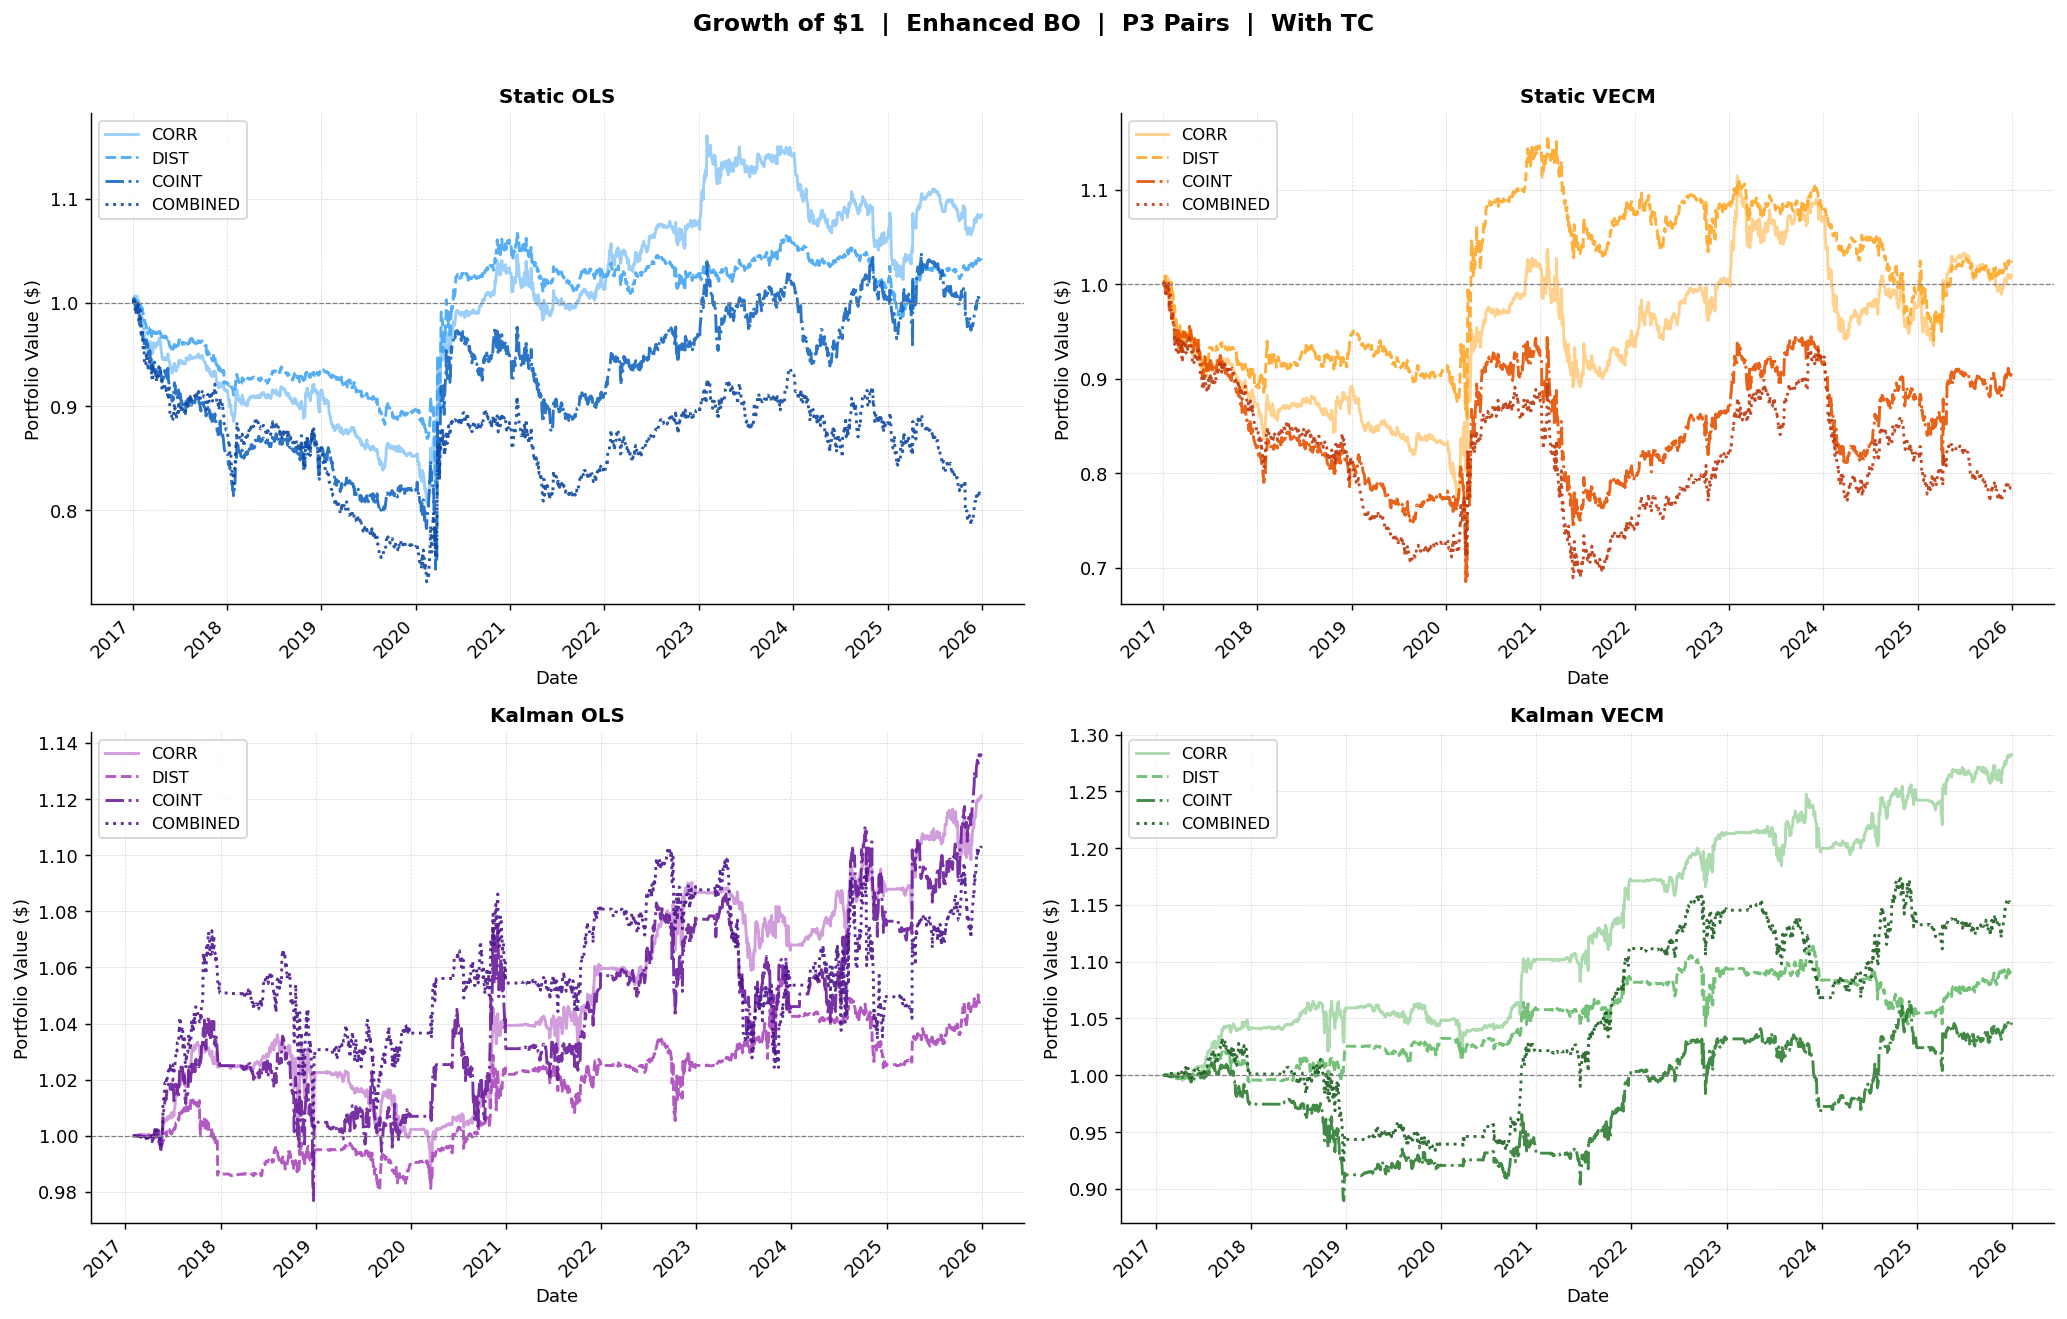

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
axes_flat = axes.flatten()

for ax, (strat_label, _, __) in zip(axes_flat, STRATEGIES):
    plotted = False
    for method in METHODS:
        color   = STRAT_PALETTES[strat_label][METHODS.index(method)]
        run_key = f'{strat_label}_{method}'
        if run_key not in results:
            continue
        df_m, df_r, _ = results[run_key]
        if df_r.empty:
            continue
        equity = df_r.sum(axis=1).cumsum().apply(np.exp)
        ax.plot(equity.index, equity.values,
                linestyle=METHOD_STYLES[method], color=color,
                linewidth=1.6, alpha=0.9, label=method.upper())
        plotted = True

    ax.axhline(1.0, color='grey', linewidth=0.7, linestyle='--')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.set_title(strat_label.replace('_', ' '), fontweight='bold', fontsize=11)
    ax.set_ylabel('Portfolio Value ($)')
    ax.set_xlabel('Date')
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5)
    if plotted:
        ax.legend(fontsize=9, loc='upper left')

fig.suptitle('Growth of $1  |  Enhanced BO  |  P3 Pairs  |  With TC',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5 · Drawdown Comparison

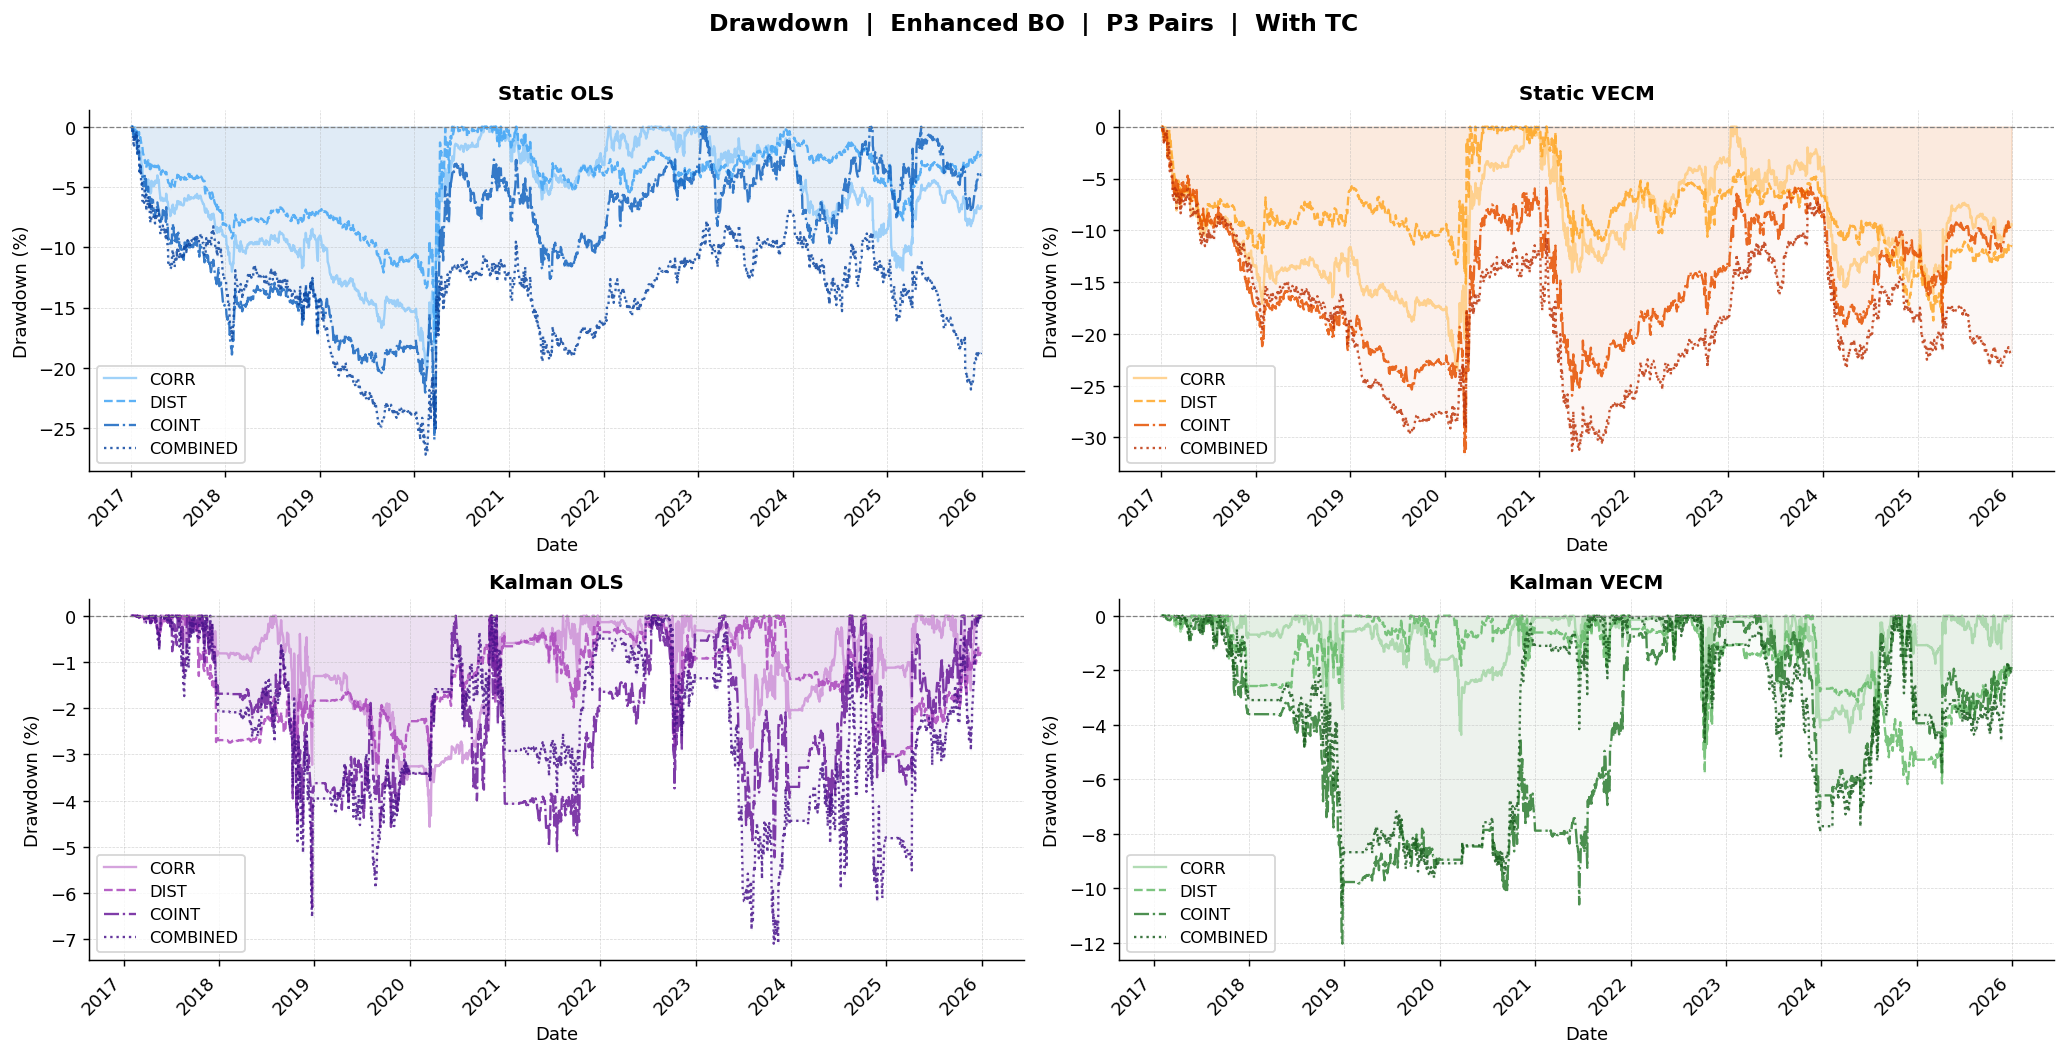

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharey=False)
axes_flat = axes.flatten()

for ax, (strat_label, _, __) in zip(axes_flat, STRATEGIES):
    for method in METHODS:
        color   = STRAT_PALETTES[strat_label][METHODS.index(method)]
        run_key = f'{strat_label}_{method}'
        if run_key not in results:
            continue
        _, df_r, _ = results[run_key]
        if df_r.empty:
            continue
        equity = df_r.sum(axis=1).cumsum().apply(np.exp)
        dd     = ((equity / equity.cummax()) - 1) * 100
        ax.plot(dd.index, dd.values,
                linestyle=METHOD_STYLES[method], color=color,
                linewidth=1.3, alpha=0.85, label=method.upper())
        ax.fill_between(dd.index, dd.values, 0, alpha=0.04, color=color)

    ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.set_title(strat_label.replace('_', ' '), fontweight='bold', fontsize=11)
    ax.set_ylabel('Drawdown (%)')
    ax.set_xlabel('Date')
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5)
    ax.legend(fontsize=9, loc='lower left')

fig.suptitle('Drawdown  |  Enhanced BO  |  P3 Pairs  |  With TC',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()